# Supervised Learning mit dem Fussballer-Datensatz

Dieses Notebook zeigt einen einfachen **Supervised-Learning-Workflow** ohne dass Sie den Algorithmus selbst programmieren müssen:

1. CSV-Datei hochladen
2. Zielvariable festlegen
3. Trainings- und Testdaten aufteilen
4. Lineare Regression trainieren
5. Vorhersagen auf Testdaten erzeugen
6. Modellgüte bewerten


In [1]:
# 1. Datei hochladen
from google.colab import files
uploaded = files.upload()


Saving Advertising.csv to Advertising.csv


In [2]:
# 2. Daten einlesen und ansehen
import io
import pandas as pd

filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# typische Index-Spalte entfernen, falls vorhanden
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print('Datensatz:', filename)
print('Zeilen und Spalten:', df.shape)
display(df.head())


Datensatz: Advertising.csv
Zeilen und Spalten: (200, 4)


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Zielvariable und Features

Beim Advertising-Datensatz ist **sales** die Zielvariable $y$.
Die Eingabevariablen $X$ sind **TV, radio und newspaper**.

In [7]:
# 3. Zielvariable und Features festlegen
TARGET = 'sales'

# Nur numerische Features verwenden
X = df[['TV']]
y = df[TARGET]

print('Features X:', list(X.columns))
print('Zielvariable y:', TARGET)


Features X: ['TV']
Zielvariable y: sales


In [8]:
# 4. Daten in Training (80 %) und Test (20 %) aufteilen
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training:', len(X_train), 'Beobachtungen')
print('Test:', len(X_test), 'Beobachtungen')


Training: 160 Beobachtungen
Test: 40 Beobachtungen


In [9]:
# 5. Lineare Regression trainieren
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print('Intercept:', round(model.intercept_, 4))
print('\nKoeffizienten:')
for feature, coef in zip(X.columns, model.coef_):
    print(f'{feature}: {coef:.4f}')


Intercept: 7.1196

Koeffizienten:
TV: 0.0465


In [10]:
# 6. Vorhersagen für bisher nicht verwendete Testdaten
y_pred = model.predict(X_test)

results = X_test.copy()
results['sales_tatsaechlich'] = y_test.values
results['sales_vorhergesagt'] = y_pred
results['fehler'] = results['sales_tatsaechlich'] - results['sales_vorhergesagt']

display(results.head(10).round(2))


,TV,sales_tatsaechlich,sales_vorhergesagt,fehler
95,163.3,16.9,14.72,2.18
15,195.4,22.4,16.21,6.19
30,292.9,21.4,20.75,0.65
158,11.7,7.3,7.66,-0.36
128,220.3,24.7,17.37,7.33
115,75.1,12.6,10.61,1.99
69,216.8,22.3,17.21,5.09
170,50.0,8.4,9.45,-1.05
174,222.4,11.5,17.47,-5.97
45,175.1,14.9,15.27,-0.37


In [14]:
# 7. Modellgüte bewerten
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R²   = {r2:.3f}')
print(f'MAE  = {mae:.3f}')
print(f'RMSE = {rmse:.3f}')


R²   = 0.677
MAE  = 2.444
RMSE = 3.194


**Interpretation:**

- **R²**: Welcher Anteil der Streuung von `sales` wird vom Modell erklärt?
- **MAE**: durchschnittlicher absoluter Vorhersagefehler
- **RMSE**: bestraft größere Vorhersagefehler stärker


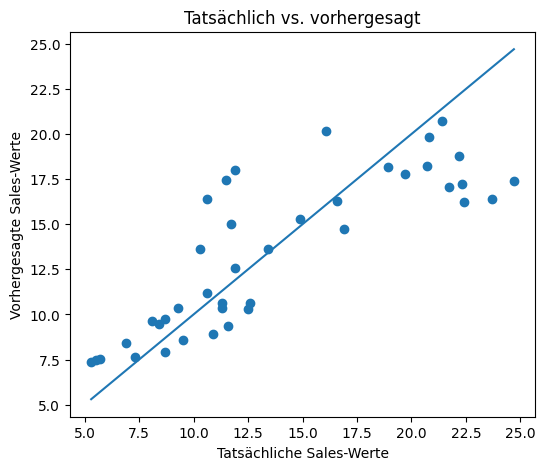

In [13]:
# 8. Tatsächliche und vorhergesagte Werte vergleichen
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred)
plt.xlabel('Tatsächliche Sales-Werte')
plt.ylabel('Vorhergesagte Sales-Werte')
plt.title('Tatsächlich vs. vorhergesagt')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()


## Reflexionsfragen

1. Was sind in diesem Beispiel die **Features X** und die **Zielvariable y**?
2. Warum handelt es sich um **Supervised Learning**?
3. Warum ist dies ein **Regressionsproblem**?
4. Warum trennen wir Trainings- und Testdaten?
5. Welche Variable hat den größten positiven Koeffizienten?
6. Wie gut sagt das Modell neue, bisher nicht zum Training verwendete Beobachtungen voraus?